# https://www.kaggle.com/datasets/uniabhi/bigmart-sales-data?select=Train.csv

In [2]:
import pandas as pd
from pandasql import sqldf

* **item_identifier**: nomor identifikasi unik untuk item tertentu
* **item_weight**: berat item
* **item_fat_content**: kandungan lemak dalam item, seperti lemak rendah dan lemak biasa
* **item_visibility**: visibilitas produk di outlet
* **item_type**: kategori produk, seperti Produk Susu, Minuman Ringan, Peralatan Rumah Tangga, dll
* **item_mrp**: Harga Eceran Tertinggi (HET) produk
* **outlet_identifier**: nomor identifikasi unik untuk outlet tertentu
* **outlet_establishment_year**: tahun outlet didirikan
* **outlet_size**: ukuran outlet, seperti kecil, sedang, dan besar
* **outlet_location_type**: jenis lokasi outlet, seperti Tier 1, 2, dan 3
* **outlet_type**: jenis outlet, seperti toko grosir atau supermarket
* **item_outlet_sales**: total penjualan produk di outlet

In [3]:
df_train = pd.read_csv('Train.csv')
df_low_fat_content = sqldf('''
select *, 
    CASE
        WHEN Item_Weight is null THEN max(Item_Weight) over()
        ELSE Item_Weight
    END as fix_Item_Weight,
    CASE
        WHEN Outlet_Size is null THEN "Small"
        ELSE Outlet_Size
    END as fix_Outlet_Size,
    CASE
        WHEN lower(Item_Fat_Content) = 'low fat' THEN 'low fat'
        WHEN Item_Fat_Content = 'LF' THEN 'low fat'
        WHEN Item_Fat_Content = 'reg' THEN 'regular'
        WHEN lower(Item_Fat_Content) = 'regular' THEN 'regular'
    END as fix_Item_Fat_Content
from df_train
''')

In [4]:
sqldf('select distinct Item_Identifier from df_train')
sqldf('select distinct Item_Type from df_train')
sqldf('select distinct Outlet_Identifier from df_train')
sqldf('select distinct Outlet_Location_Type from df_train')
sqldf('select distinct Outlet_Type from df_train')
sqldf('select count(Outlet_Size) from df_train where Outlet_Size is null')

,count(Outlet_Size)
0,0


In [5]:
df_train.dtypes

Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
dtype: object

# Data visualisas

In [6]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------- Histogram -----------------

* Histogram adalah jenis diagram batang yang menggambarkan distribusi data numerik dengan membagi data ke dalam
 interval (juga dikenal sebagai bin) dan menghitung berapa banyak nilai yang jatuh ke dalam setiap bin. Setiap batang 
 dalam histogram mewakili frekuensi (jumlah) atau probabilitas (frekuensi relatif) dari titik data dalam setiap bin. 
 Tinggi batang menunjukkan frekuensi titik data yang jatuh ke dalam setiap interval. Histogram umumnya digunakan dalam 
 statistik untuk memberikan representasi visual dari distribusi dataset.

In [17]:
fig_histogram = make_subplots(rows=df_train.shape[1], cols=1)
for i, col in enumerate(df_train.columns):
    fig_histogram.add_trace(go.Histogram(x=df_train[col], name=col), row=i + 1, col=1)
    fig_histogram.update_xaxes(title_text=col,row=i+1,col=1)
    fig_histogram.update_yaxes(title_text='count',row=i+1,col=1)
fig_histogram.update_layout(height=3000)
fig_histogram.write_html(f"{os.getcwd()}/fig_histogram.html")


<Axes: xlabel='Outlet_Type', ylabel='count'>

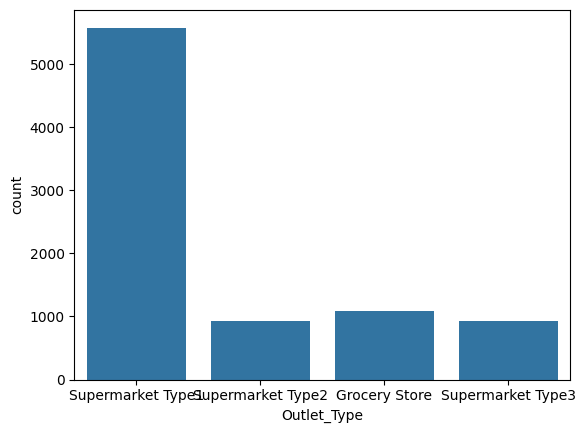

In [15]:
# histogram for categorical using sns

sns.countplot(x='Outlet_Type',data=df_train)

<Axes: xlabel='Outlet_Size', ylabel='count'>

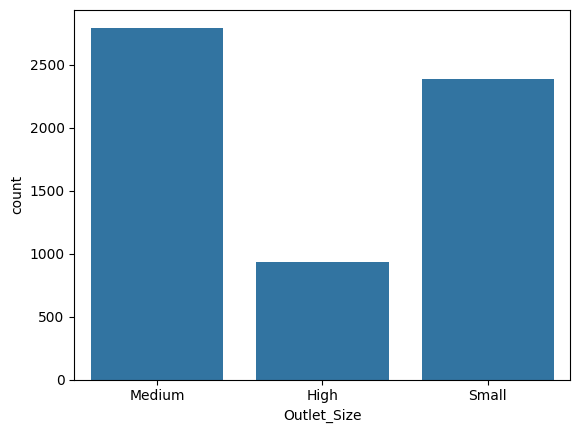

In [16]:
sns.countplot(x='Outlet_Size',data=df_train)

<Axes: xlabel='Item_Weight', ylabel='Count'>

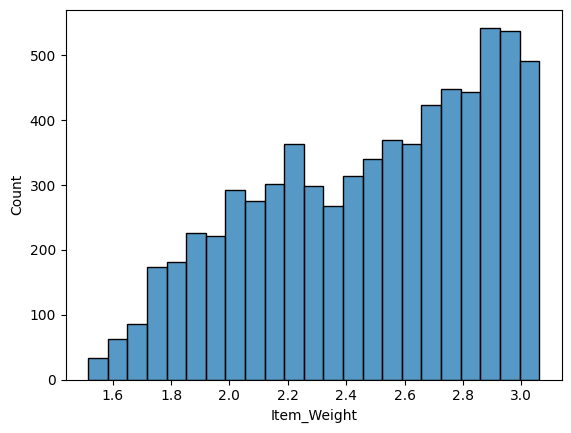

In [18]:
# histogram for numerical using sns
sns.histplot(np.log(df_train['Item_Weight']))


<Axes: xlabel='Item_MRP', ylabel='Count'>

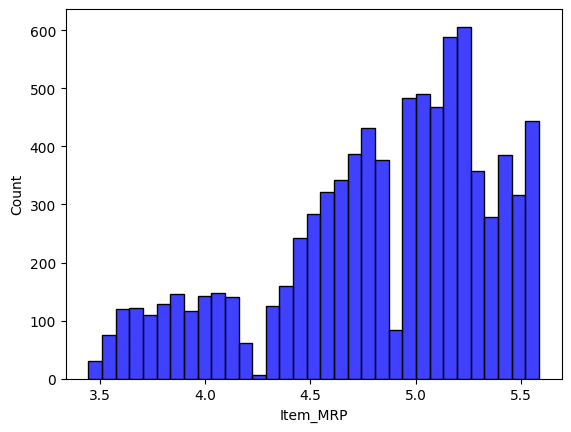

In [19]:
sns.histplot(np.log(df_train['Item_MRP']),color='blue')

In [12]:
target = 'Item_Outlet_Sales'
X = df_train.dropna().drop(target, axis=1)
y = df_train.dropna()[target]

# -------------------- Univariate numerical analysis -----------------

* Analisis univariat adalah jenis analisis data yang fokus pada pemahaman dan merangkum karakteristik dari
 sebuah variabel tunggal dalam sebuah dataset. Analisis ini biasanya merupakan langkah pertama dalam analisis statistik,
 dengan tujuan untuk menggambarkan data dan menemukan pola-pola yang ada di dalamnya.

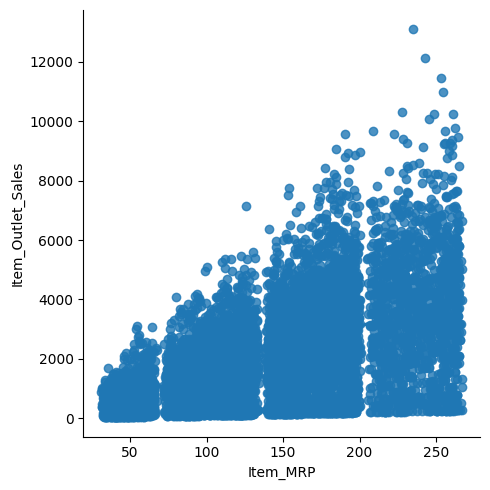

In [13]:
fig_univariate = make_subplots(rows=X.select_dtypes(include=np.number).shape[1], cols=1)
for i, col in enumerate(X.select_dtypes(include=np.number).columns):
    fig_univariate.add_trace(go.Scatter(x=X[col], y=y, name=col, mode="markers"), row=i + 1, col=1)
    fig_univariate.update_xaxes(title_text=col,row=i+1,col=1)
    fig_univariate.update_yaxes(title_text=target,row=i+1,col=1)
fig_univariate.update_layout(height=3000)
fig_univariate.write_html(f"{os.getcwd()}/fig_univariate.html")
# univariate using sns
sns.lmplot(data=df_train, x="Item_MRP",y="Item_Outlet_Sales")

# -------------------- Univariate categorical analysis -----------------

In [14]:
fig_univariate_categorical = make_subplots(rows=X.select_dtypes(object).shape[1], cols=1)
for i, col in enumerate(X.select_dtypes(object).columns):
    fig_univariate_categorical.add_trace(go.Box(x=X[col], y=y, name=col), row=i + 1, col=1)
    fig_univariate_categorical.update_xaxes(title_text=col,row=i+1,col=1)
    fig_univariate_categorical.update_yaxes(title_text=target,row=i+1,col=1)
fig_univariate_categorical.update_layout(height=3000)
fig_univariate_categorical.write_html(f"{os.getcwd()}/fig_univariate_categorical.html")

# -------------------- Bivariate (w.r.t target) analysis -----------------

* Analisis bivariat adalah bentuk analisis statistik yang melibatkan penyelidikan dua variabel
  secara bersamaan untuk menentukan hubungan empiris di antara keduanya. Analisis ini membantu untuk memahami
  asosiasi, korelasi, dan potensi hubungan kausal antara kedua variabel tersebut.


In [12]:
from itertools import combinations
col_pairs = list(combinations(X.select_dtypes(object).columns, 2))
fig_bivariate_boxplot = make_subplots(rows=len(col_pairs), cols=1)
for i, (col1, col2) in enumerate(col_pairs):
    paired_cat = col1 + '=' + X[col1] + ', ' + col2 + '=' + X[col2]
    fig_bivariate_boxplot.add_trace(go.Box(x=paired_cat, y=y, name=f'{col1} & {col2}'), row=i+1, col=1)
    fig_bivariate_boxplot.update_xaxes(title_text=f'{col1} & {col2}',row=i+1,col=1)
    fig_bivariate_boxplot.update_yaxes(title_text=target,row=i+1,col=1)
fig_bivariate_boxplot.update_layout(height=20000)
fig_bivariate_boxplot.write_html(f"{os.getcwd()}/fig_bivariate_boxplot.html")

# -------------------- Collinearity (correlation) analysis -----------------

* Analisis kolinearitas melibatkan pemeriksaan hubungan di antara beberapa variabel prediktor dalam model statistik
  untuk mengidentifikasi apakah mereka memiliki korelasi yang tinggi. Korelasi antara variabel independen ini dikenal sebagai
  kolinearitas atau multikolinearitas ketika melibatkan lebih dari dua variabel.

* Implikasi
  * Presisi yang Berkurang: Kolinearitas yang tinggi meningkatkan kesalahan standar koefisien, yang menyebabkan estimasi yang kurang presisi.
  * Koefisien yang Tidak Stabil: Perubahan kecil pada data dapat menyebabkan perubahan besar pada koefisien model.
  * Tantangan dalam Interpretasi: Menjadi sulit untuk membedakan efek individu dari prediktor yang saling berkorelasi terhadap variabel respons.

* Resolusi:
  * Menghapus Variabel: Menghilangkan satu atau lebih variabel yang berkorelasi untuk mengurangi kolinearitas.
  * Analisis Komponen Utama (PCA): Mengubah prediktor menjadi seperangkat variabel yang lebih kecil dan tidak berkorelasi.
  * Teknik Regularisasi: Menerapkan metode seperti regresi Ridge atau Lasso, yang dapat menangani kolinearitas dengan memberikan penalti pada koefisien besar.


<Axes: >

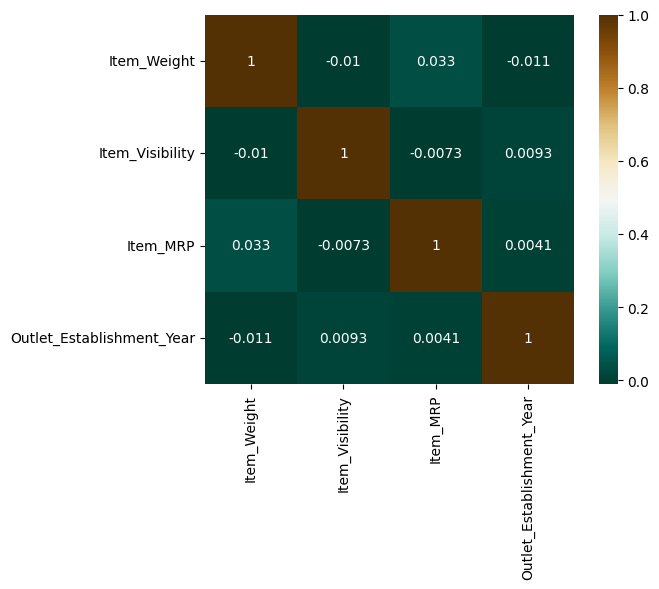

In [13]:
import plotly.express as px
px.scatter_matrix(X.select_dtypes(include=np.number)).write_html(f"{os.getcwd()}/collinearity.html")
corr = X.select_dtypes(include=np.number).corr()
px.imshow(corr).write_html(f"{os.getcwd()}/pearson_correlation.html")
# using sns
sns.heatmap(corr,cbar=True,square=True,annot=True,cmap='BrBG_r')

# -------------------- Categorical features correlation Chi-Squared --------------------

* Jenis-Jenis Uji Chi-Squared:
  * Uji Independen: Memeriksa apakah dua variabel kategorikal saling independen.
  * Kesesuaian Model: Menentukan apakah sampel sesuai dengan distribusi yang diharapkan.

* Uji Chi-Squared untuk independensi memeriksa apakah ada hubungan antara dua fitur kategorikal. Uji ini
  umumnya digunakan ketika Anda ingin menyelidiki apakah perubahan pada satu variabel kategorikal independen dari perubahan
  pada variabel kategorikal lainnya.

* Keputusan Berdasarkan Uji
  * Menolak Hipotesis Nol: Jika nilai p lebih kecil dari tingkat signifikansi yang dipilih (umumnya 0,05), Anda menolak hipotesis nol,
    dan menyimpulkan bahwa ada asosiasi yang signifikan secara statistik antara kedua variabel kategorikal.
  * Gagal Menolak Hipotesis Nol: Jika nilai p lebih besar dari tingkat signifikansi, Anda gagal menolak hipotesis nol,
    yang menyarankan tidak ada asosiasi signifikan antara variabel-variabel tersebut.


In [14]:
import scipy.stats as stats
col_pairs = list(combinations(X.select_dtypes(object), 2))
results_list=[]
for col1, col2 in col_pairs:
    contingency = pd.crosstab(X[col1], X[col2])
    chi2, p_val, dof, exp_freq = stats.chi2_contingency(contingency.values, correction=True)
    results_list.append([col1, col2, chi2, p_val, dof])
X_chi2 = pd.DataFrame(results_list,columns=['column1', 'column2', 'chi_squared', 'p_value', 'dof'])
X_chi2[X_chi2['p_value'] < 0.05]

,column1,column2,chi_squared,p_value,dof
0,Item_Identifier,Item_Fat_Content,9128.333294,4.368940e-123,6136
1,Item_Identifier,Item_Type,69750.000000,0.000000e+00,23010
6,Item_Fat_Content,Item_Type,872.011112,1.878187e-144,60
15,Outlet_Identifier,Outlet_Size,9300.000000,0.000000e+00,8
16,Outlet_Identifier,Outlet_Location_Type,9300.000000,0.000000e+00,8
17,Outlet_Identifier,Outlet_Type,4650.000000,0.000000e+00,4
18,Outlet_Size,Outlet_Location_Type,3490.002691,0.000000e+00,4
19,Outlet_Size,Outlet_Type,1742.184978,0.000000e+00,2
20,Outlet_Location_Type,Outlet_Type,1739.065019,0.000000e+00,2


# -------------------- cramers v test --------------------

* Uji Chi-Squared: Nilai statistik Chi-Squared itu sendiri dapat meningkat seiring dengan ukuran sampel atau jumlah kategori,
  yang membuatnya sulit untuk diinterpretasikan tanpa konteks.
* Cramér's V: Menyediakan ukuran asosiasi yang dinormalisasi antara 0 dan 1, terlepas dari ukuran tabel dan ukuran sampel.
  Hal ini membuatnya jauh lebih mudah untuk memahami kekuatan asosiasi. Nilai Cramér's V yang lebih tinggi menunjukkan asosiasi yang lebih kuat,
  memberikan metrik yang lebih jelas dan lebih mudah dipahami.

* Uji Chi-Squared: Meskipun berguna, hasilnya lebih fokus pada apakah hipotesis independensi dapat ditolak. Hasil biner ini
  (menolak atau tidak menolak hipotesis) mungkin tidak memberikan wawasan mendalam tentang bagaimana variabel saling berinteraksi.
* Cramér's V: Menawarkan ukuran kuantitatif yang dapat dengan mudah dilaporkan dan diinterpretasikan sebagai ukuran
  kekuatan asosiasi, yang sangat berguna dalam laporan dan analisis mendalam di mana pemahaman tentang tingkat hubungan sangat penting.


In [15]:
from sklearn import preprocessing
label=preprocessing.LabelEncoder()
data_encoded=pd.DataFrame()
for i in df_train[['Outlet_Type','Outlet_Size','Outlet_Location_Type']].columns:
    data_encoded[i]=label.fit_transform(df_train[i])

In [16]:
results = []
for var1 in data_encoded:
    col=[]
    for var2 in data_encoded:
        contingency = pd.crosstab(data_encoded[var1],data_encoded[var2])
        chi2, p_val, dof, exp_freq = stats.chi2_contingency(contingency.values, correction=True)
        obs=data_encoded.shape[0]
        var3=min(contingency.values.shape)-1
        cramers2 = (chi2/(obs*var3))
        col.append(round(cramers2,2))
    results.append(col)
result_cv=pd.DataFrame(results,columns=data_encoded.columns,index=data_encoded.columns)

# -------------------- numerical and categorical feature correlation - ANOVA --------------------

* One-way ANOVA: Menguji perbedaan signifikan antara rata-rata tiga kelompok atau lebih yang independen (tidak terkait).
  Tipe ini digunakan ketika terdapat satu variabel independen kategorikal dan satu variabel dependen kontinu.
* Two-way ANOVA: Menguji perbedaan yang terkait dengan dua variabel kategorikal independen, yang dapat saling berinteraksi
  dalam mempengaruhi variabel dependen. Ini dapat digunakan untuk memahami apakah ada efek interaksi antara
  dua variabel independen pada variabel dependen.

* Meskipun ANOVA itu sendiri tidak mengukur korelasi secara langsung, secara konseptual dapat terkait:
  * Data Kategorikal dan Kontinu: ANOVA dapat dianggap sebagai perpanjangan dari konsep pengujian korelasi
    dari variabel kontinu murni (seperti dalam korelasi Pearson) ke skenario di mana Anda memiliki variabel independen kategorikal
    dan variabel dependen kontinu.
  * Ukuran Efek: Setelah melakukan ANOVA, Anda mungkin menghitung ukuran efek, yang memberikan ukuran kekuatan hubungan
    antara variabel independen dan dependen. 
  * Ukuran efek yang umum termasuk Eta-squared atau Omega-squared, yang mirip dalam interpretasinya dengan
    koefisien korelasi namun khusus untuk konteks ANOVA.


In [17]:
from itertools import product
num_cols = X.select_dtypes(np.number).columns
cat_cols = X.select_dtypes(object).columns
col_pairs = list(product(num_cols, cat_cols))
results_list = []
for num_col, cat_col in col_pairs:
    X_filtered_list = []
    cat_values = X[cat_col].unique()
    for cat_value in cat_values:
        X_filtered_list.append(X[X[cat_col] == cat_value][num_col].values)
    f_stat, p_val = stats.f_oneway(*X_filtered_list)
    results_list.append([num_col, cat_col, f_stat, p_val])
results = pd.DataFrame(results_list,columns=['num_column', 'cat_column', 'f_stat', 'p_value'])
results[results['p_value'] < 0.05]

c:\Users\Faliq\Downloads\Code+and+data (3)\.venv\Lib\site-packages\scipy\stats\_stats_py.py:4167: ConstantInputWarning:

Each of the input arrays is constant;the F statistic is not defined or infinite



,num_column,cat_column,f_stat,p_value
0,Item_Weight,Item_Identifier,inf,0.000000e+00
2,Item_Weight,Item_Type,5.488714,3.377912e-11
7,Item_Visibility,Item_Identifier,12.507853,0.000000e+00
8,Item_Visibility,Item_Fat_Content,4.357710,1.614463e-03
9,Item_Visibility,Item_Type,3.088182,5.019240e-05
14,Item_MRP,Item_Identifier,8275.176260,0.000000e+00
16,Item_MRP,Item_Type,4.383299,2.932246e-08
24,Outlet_Establishment_Year,Outlet_Identifier,inf,0.000000e+00
25,Outlet_Establishment_Year,Outlet_Size,6194.245312,0.000000e+00
26,Outlet_Establishment_Year,Outlet_Location_Type,275.338107,9.839599e-114


# -------------------- correlation of numerical with respect to target (Pearson's correlation) --------------------

In [18]:
data_corr = df_train.select_dtypes(np.number).corr()
data_corr.index.name = 'features'
data_corr = data_corr.reset_index()
data_corr = data_corr[data_corr['features'] != y.name]
fig_correlation_wrt_target = px.bar(
    data_frame=data_corr.reset_index(),
    x='features',
    y=target
)
fig_correlation_wrt_target.update_yaxes(title='correlation')
fig_correlation_wrt_target.write_html(f"{os.getcwd()}/fig_correlation_wrt_target.html")

# -------------------- correlation of categorical with respect to target (ANOVA test) --------------------

In [19]:
num_cols = df_train.select_dtypes(np.number).columns
cat_cols = df_train.select_dtypes(object).columns
col_pairs = list(product(num_cols, cat_cols))
results_list = []
for num_col, cat_col in col_pairs:
    X_filtered_list = []
    cat_values = X[cat_col].unique()
    for cat_value in cat_values:
        X_filtered_list.append(df_train[df_train[cat_col] == cat_value][num_col].values)
    f_stat, p_val = stats.f_oneway(*X_filtered_list)
    results_list.append([num_col, cat_col, f_stat, p_val])
results = pd.DataFrame(results_list,columns=['num_column', 'cat_column', 'f_stat', 'p_value'])
results[results['num_column']==target][results['p_value'] < 0.05]

c:\Users\Faliq\Downloads\Code+and+data (3)\.venv\Lib\site-packages\scipy\stats\_stats_py.py:4167: ConstantInputWarning:

Each of the input arrays is constant;the F statistic is not defined or infinite

C:\Users\Faliq\AppData\Local\Temp\ipykernel_18288\3122049077.py:13: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



,num_column,cat_column,f_stat,p_value
28,Item_Outlet_Sales,Item_Identifier,3.341869,4.928387e-251
30,Item_Outlet_Sales,Item_Type,2.700653,3.884399e-04
31,Item_Outlet_Sales,Outlet_Identifier,11.576494,2.362745e-09
32,Item_Outlet_Sales,Outlet_Size,131.096694,1.791275e-56
33,Item_Outlet_Sales,Outlet_Location_Type,53.947740,5.222817e-24
34,Item_Outlet_Sales,Outlet_Type,36.519200,1.595332e-09


# -------------------- feature engineering & data cleanup--------------------

In [20]:
df_train['Item_Weight'] = df_train['Item_Weight'].fillna(df_train.groupby('Item_Identifier')['Item_Weight'].transform('max'))
df_train=df_train[df_train['Item_Weight'].notna()]
df_train['Outlet_Size'] = df_train['Outlet_Size'].fillna("Small")
df_train.replace({'Item_Fat_Content':{'low fat':'Low Fat','LF':'Low Fat','reg':'Regular'}},inplace=True)
df_train['Outlet_Age'] =2024 - df_train['Outlet_Establishment_Year']
df = df_train.drop(columns=['Outlet_Establishment_Year'])

# -------------------- encode categorical variables --------------------

In [21]:
col_encode=['Item_Fat_Content','Outlet_Identifier','Outlet_Size','Outlet_Location_Type','Outlet_Type']
for i in col_encode:
    df[i]=preprocessing.LabelEncoder().fit_transform(df[i])
df_new=df.drop(columns=['Item_Identifier'])
df_new=pd.get_dummies(df_new)
df_new.head()


,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age,...,Item_Type_Fruits and Vegetables,Item_Type_Hard Drinks,Item_Type_Health and Hygiene,Item_Type_Household,Item_Type_Meat,Item_Type_Others,Item_Type_Seafood,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods
0,9.30,0,0.016047,249.8092,9,1,0,1,3735.1380,25,...,False,False,False,False,False,False,False,False,False,False
1,5.92,1,0.019278,48.2692,3,1,2,2,443.4228,15,...,False,False,False,False,False,False,False,False,True,False
2,17.50,0,0.016760,141.6180,9,1,0,1,2097.2700,25,...,False,False,False,False,True,False,False,False,False,False
3,19.20,1,0.000000,182.0950,0,2,2,0,732.3800,26,...,True,False,False,False,False,False,False,False,False,False
4,8.93,0,0.000000,53.8614,1,0,2,1,994.7052,37,...,False,False,False,True,False,False,False,False,False,False


# -------------------- data pre processing --------------------

In [22]:
from sklearn.model_selection import train_test_split
X=df_new.drop(columns=['Item_Outlet_Sales'])
y=df_new['Item_Outlet_Sales']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=11)

# -------------------- modeling --------------------
# 1. Linear Regression (LR)

* Mekanisme: Mengasumsikan hubungan linier antara fitur input dan variabel target. Menyesuaikan garis lurus (atau
  hiperbidang dalam dimensi yang lebih tinggi) yang meminimalkan jumlah kuadrat residual (perbedaan antara nilai yang diamati dan
  nilai yang diprediksi).
* Kasus Penggunaan: Tugas prediktif sederhana di mana data diperkirakan mengikuti tren linier. Tidak cocok untuk pola dan hubungan yang kompleks.

# 2. Elastic Net

* Tipe: Regresi parametrik yang menggabungkan regularisasi L1 dan L2.
* Mekanisme: Meminimalkan fungsi biaya model yang dipenalti yang mencakup penalti L1 (lasso) dan L2 (ridge). Kombinasi ini
  memungkinkan untuk mempelajari model yang mempertahankan kelangkaan sambil juga mempertimbangkan multikolinearitas di antara fitur.
* Kasus Penggunaan: Berguna dalam situasi dengan banyak fitur, mungkin dengan multikolinearitas, atau ketika seleksi fitur
  penting.

# 3. Random Forest Regressor (RF)

* Tipe: Ensemble, berdasarkan pohon keputusan.
* Mekanisme: Membangun beberapa pohon keputusan selama pelatihan dan menghasilkan prediksi rata-rata dari pohon individu.
  Ini menggunakan bagging (Bootstrap Aggregating) untuk mengurangi varians model.
* Kasus Penggunaan: Sangat baik untuk menangani data non-linier dengan hubungan dan interaksi yang kompleks. Tahan terhadap
  overfitting jika dibandingkan dengan pohon keputusan tunggal.

# 4. Extra Trees Regressor (ETR)

* Tipe: Ensemble dari pohon yang sangat acak.
* Mekanisme: Mirip dengan random forests, tetapi pohon dibangun dari seluruh set pelatihan daripada sampel bootstrap,
  dan pembagian dipilih lebih acak. Keacakan ini dapat membantu mengurangi varians model.
* Kasus Penggunaan: Baik untuk model di mana peningkatan keacakan dan kecepatan sangat menguntungkan. Sering kali lebih cepat
  daripada random forest tradisional.

# 5. Gradient Boosting Regressor (GBM)

* Tipe: Ensemble, pendekatan berbasis boosting.
* Mekanisme: Membangun pohon secara berurutan, dengan setiap pohon baru mencoba untuk memperbaiki kesalahan pohon sebelumnya. Ini
  menggunakan gradient descent untuk meminimalkan kerugian ketika menambahkan model baru.
* Kasus Penggunaan: Sangat efektif untuk dataset kompleks dengan pola non-linier tetapi bisa rentan terhadap overfitting. Sering
  digunakan dalam kompetisi machine learning.

# 6. MLP Regressor (Multilayer Perceptron)

* Tipe: Regresi berbasis jaringan saraf.
* Mekanisme: Terdiri dari setidaknya tiga lapisan (input, tersembunyi, dan output) dan dapat memodelkan hubungan non-linier
  melalui jaringan. Pembelajaran umumnya dilakukan melalui backpropagation.
* Kasus Penggunaan: Cocok untuk masalah regresi yang kompleks dan berskala besar di mana metode tradisional tidak memadai. Fleksibel
  tetapi memerlukan penalaan parameter yang hati-hati, seperti jumlah lapisan tersembunyi dan node, fungsi aktivasi,
  dan regularisasi.


In [23]:
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score

In [24]:
models=[('lr',LinearRegression()),('ElasticNet',ElasticNet()),('RF',RandomForestRegressor()),
         ('ETR',ExtraTreesRegressor()),('GBM',GradientBoostingRegressor()),('MLP',MLPRegressor())]
scores=[]
names=[]
cross_folds=3
for i, j in models:
    cv_scores=cross_val_score(j,X_train,y_train,cv=cross_folds,n_jobs=-1)
    scores.append(cv_scores)
    names.append(i)
for k in range(len(scores)):
    print(names[k],scores[k].mean())

lr 0.4986252746356907
ElasticNet 0.4757125167826122
RF 0.5544701522008056
ETR 0.5032738131566025
GBM 0.5934725516188376
MLP 0.47420620677392405


# 7. VotingRegressor: Membuat rata-rata dari prediksi model

* Voting regressor adalah meta-estimator ensemble yang menyesuaikan beberapa base regressor, masing-masing pada seluruh dataset. Kemudian
  ia merata-ratakan prediksi individu untuk membentuk prediksi akhir.


In [25]:
from sklearn.ensemble import VotingRegressor
reg1=LinearRegression()
reg2=GradientBoostingRegressor()
reg3=MLPRegressor()
voting_regress=VotingRegressor(estimators=[('LR',reg1),('GBM',reg2),('MLP',reg3)])
scores=cross_val_score(voting_regress,X_train,y_train,cv=3)
print(scores)
print(scores.mean())

c:\Users\Faliq\Downloads\Code+and+data (3)\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.

c:\Users\Faliq\Downloads\Code+and+data (3)\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



[0.5616355  0.55332365 0.5437715 ]
0.5529102163531864


c:\Users\Faliq\Downloads\Code+and+data (3)\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



# 8. StackingRegressor: model stacking

* Stacked generalization terdiri dari menumpuk output dari estimator individu dan menggunakan regressor untuk menghitung
  prediksi akhir. Stacking memungkinkan untuk memanfaatkan kekuatan setiap estimator individu dengan menggunakan output mereka
  sebagai input untuk estimator akhir.


In [26]:
from sklearn.metrics import r2_score
from sklearn.ensemble import StackingRegressor
reg1=LinearRegression()
reg2=GradientBoostingRegressor()
estimators=[('LR',reg1),('GBM',reg2)]
level_1_estimator= MLPRegressor()
stacking_model= StackingRegressor(estimators=estimators,final_estimator=level_1_estimator)
scores=cross_val_score(stacking_model,X_train,y_train,cv=3)
scores

array([0.59989916, 0.59126965, 0.59234358])

In [27]:
model_stack=stacking_model.fit(X_train,y_train)
y_pred=model_stack.predict(X_test)
print("R2 of Stacking is")
print(r2_score(y_test,y_pred))

R2 of Stacking is
0.599623218650918


# 9. GAM - Generalized Additive Models

* Tidak seperti model linier yang mengasumsikan hubungan garis lurus antara variabel, GAM menggunakan fungsi halus (seperti
  splines, polinomial, atau jenis fungsi basis halus lainnya) untuk memodelkan perilaku kompleks antara variabel
  tanpa menentukan bentuk hubungan tertentu.


In [29]:
from pygam import LinearGAM, PoissonGAM,GammaGAM
gam = GammaGAM(n_splines=5).fit(X_train,y_train)
y_pred=gam.predict(X_test.values)
print(r2_score(y_test,y_pred))

0.6098660623971285


In [30]:
gam = PoissonGAM(n_splines=5).fit(X_train,y_train)
y_pred=gam.predict(X_test.values)
print(r2_score(y_test,y_pred))

c:\Users\Faliq\Downloads\Code+and+data (3)\.venv\Lib\site-packages\pygam\pygam.py:2873: FutureWarning:

Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.



did not converge
0.6064416703733768


# 10 GBM - Gradient Boosting Method.

* Ini adalah algoritma machine learning ensemble yang digunakan untuk tugas regresi dan klasifikasi. Metode ini membangun
  model secara bertahap seperti halnya metode boosting lainnya, dan menggeneralisasikannya dengan memungkinkan optimisasi
  fungsi kerugian diferensial sembarang.

* Teknik Ensemble: GBM menggabungkan beberapa model prediktif lemah, biasanya pohon keputusan, menjadi pembelajar kuat
  secara berurutan.
* Strategi Boosting: Dalam boosting, setiap model baru secara bertahap memperbaiki model sebelumnya, sehingga disebut
  "boosting". GBM melakukan ini dengan fokus pada contoh yang paling sulit untuk diprediksi, yaitu, ia menekankan residual
  atau kesalahan dari model sebelumnya dan mencoba untuk memperbaikinya di iterasi berikutnya.


In [31]:
model_gbm=GradientBoostingRegressor()
model_gbm.fit(X_train,y_train)
y_pred=model_gbm.predict(X_test)
print("R2 of GBM is")
print(r2_score(y_test,y_pred))

R2 of GBM is
0.5979358359116055


# XGBoost - eXtreme Gradient Boosting

## Manfaat
* Kinerja dan Skalabilitas
* Penanganan Dataset Besar
* Regularisasi
* Fleksibilitas
* Penanganan Data yang Hilang
* Pemangkasan Pohon
* Cross-Validation Bawaan
* Pelatihan Lanjutan

## Cara Kerja
* Ensemble Pohon: XGBoost membangun ensemble pohon keputusan secara berurutan. Setiap pohon
  memperbaiki kesalahan dari pohon sebelumnya.
* Gradient Boosting: Metode ini menggunakan gradient descent untuk meminimalkan loss
  saat menambahkan model baru. Setiap pohon baru dipasang pada kesalahan residual dari prediksi sebelumnya.
* Regularisasi: Model ini menerapkan regularisasi L1 dan L2 pada fungsi biaya yang digunakan dalam proses pembelajaran pohon,
  yang meningkatkan generalisasi model dan mengontrol kompleksitas.


In [32]:
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from skopt.space import Real, Categorical, Integer
from skopt import BayesSearchCV

In [33]:
rfe = RFE(estimator=XGBRegressor())
xgb = XGBRegressor()
steps = [('rfe', rfe),('xgb', xgb)]
pipe = Pipeline(steps)

In [34]:
num_features = X_train.shape[1]
search_spaces = {
    'rfe__n_features_to_select': Integer(1, num_features), # Num features returned by RFE
    'xgb__n_estimators': Integer(1, 500), # Num trees built by XGBoost
    'xgb__max_depth': Integer(2, 8), # Max depth of trees built by XGBoost
    'xgb__reg_lambda': Integer(1, 200), # Regularisation term (lambda) used in XGBoost
    'xgb__learning_rate': Real(0, 1), # Learning rate used in XGBoost
    'xgb__gamma': Real(0, 2000) # Gamma used in XGBoost
}

In [35]:
xgb_bs_cv = BayesSearchCV(
    estimator=pipe, # Pipeline
    search_spaces=search_spaces, # Search spaces
    scoring='neg_root_mean_squared_error', # BayesSearchCV tries to maximise scoring metric, so negative RMSE used
    n_iter=75, # Num of optimisation iterations
    cv=3, # Number of folds
    n_jobs=-1, # Uses all available cores to compute
    verbose=1, # Show progress
    random_state=0 # Ensures reproducible results
)

In [36]:
xgb_bs_cv.fit(X_train,y_train)

y_pred_train_xgb = xgb_bs_cv.predict(X_train)
y_pred_test_xgb = xgb_bs_cv.predict(X_test)
r2_score(y_train, y_pred_train_xgb)
r2_score(y_test, y_pred_test_xgb)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

0.6042349031564865